In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [2]:
data = pd.read_parquet('../data/data_full_cleaned_noimpute.parquet')
data

,T,objID,ra,dec,imputed_brightness,sb50_r,sb_conc_r,ug_color,ur_color,ui_color,uz_color,gr_color,gi_color,gz_color,ri_color,rz_color,iz_color,morphology
index,,,,,,,,,,,,,,,,,,
1,1.000,1.237680e+18,0.036130,-6.374014,0,21.069490,2.590016,1.38158,2.13592,2.53666,2.88048,0.75434,1.15508,1.49890,0.40074,0.74456,0.34382,spiral
12,-1.616,1.237680e+18,0.195709,28.402031,0,19.962552,3.291443,2.04367,2.91089,3.35135,3.64608,0.86722,1.30768,1.60241,0.44046,0.73519,0.29473,ellipt
23,2.000,1.237681e+18,0.309253,34.675786,0,20.911888,2.625550,1.93849,2.85876,3.29540,3.64567,0.92027,1.35691,1.70718,0.43664,0.78691,0.35027,spiral
28,0.000,1.237679e+18,0.333240,13.111274,0,19.198623,2.945395,1.50422,2.28660,2.70037,2.98247,0.78238,1.19615,1.47825,0.41377,0.69587,0.28210,spiral
39,3.010,1.237679e+18,0.427388,23.493838,0,20.812663,2.279652,1.45037,2.18329,2.59242,2.95547,0.73292,1.14205,1.50510,0.40913,0.77218,0.36305,spiral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22956,4.000,1.237673e+18,359.198027,1.355186,0,20.988229,2.555702,1.44319,2.12479,2.48095,2.75974,0.68160,1.03776,1.31655,0.35616,0.63495,0.27879,spiral
22966,2.000,1.237680e+18,359.276728,29.839112,0,20.535076,2.338736,1.43906,2.16878,2.49947,2.77788,0.72972,1.06041,1.33882,0.33069,0.60910,0.27841,spiral
22992,4.000,1.237673e+18,359.738531,-2.249577,0,21.120630,2.600354,1.72847,2.46468,2.83218,3.11370,0.73621,1.10371,1.38523,0.36750,0.64902,0.28152,spiral


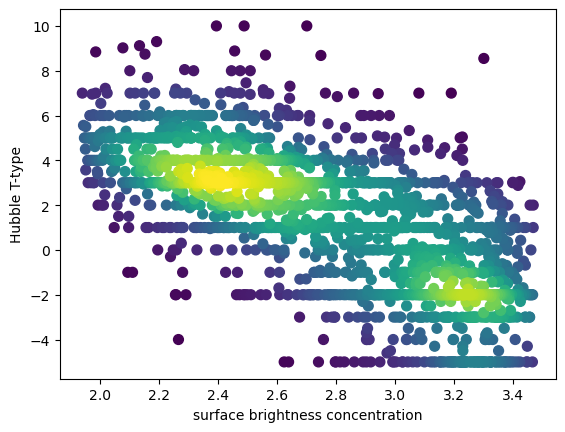

In [3]:
x = data['sb_conc_r'].to_numpy()
y = data['T'].to_numpy()

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

fig, ax = plt.subplots()
ax.scatter(x, y, c=z, s=50)
ax.set_xlabel('surface brightness concentration')
ax.set_ylabel('Hubble T-type')
plt.show()